<a href="https://colab.research.google.com/github/RixzFahad/Machine-Learning/blob/main/ML_ProjectFirst_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Cancer Detection***

*Test Case*
From the given dataset (Wbc.csv), we need to predict the presence of cancer

**Information about the Data**
* This CSV file contains test reports of different white blood cells
* Features include cell size, shape, and other medical attributes

***Objective***
* Predict whether cancer is present or not

**Type of Problem**
* Supervised Learning
* Classification (binary: Cancer / No Cancer)

**Input**
* White blood cell features from dataset

**Output**
* Prediction: Cancer present or not

***Goal***
* Build a model that accurately classifies new/unseen patient data

## ***Step One: Libraries***

In [4]:
#Import Neccessary Libraries-

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/wbc.csv")

In [7]:
df.tail(9)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
560,925292,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.1048,0.2250,0.08321,NaN
561,925311,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.0000,0.1566,0.05905,NaN
562,925622,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.2356,0.4089,0.14090,NaN
563,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873,NaN
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


## ***Step Two: Data Overview***

Let's begin by examining the overall structure and characteristics of our dataset. This includes checking its shape (number of rows and columns), data types of each column, and basic descriptive statistics to understand the distribution of numerical features.

### Dataset Shape

In [8]:
# Check the shape of the DataFrame
display(f"Shape of the DataFrame: {df.shape}")

'Shape of the DataFrame: (569, 33)'

### Dataset Information (Data Types and Non-Null Counts)

In [9]:
# Get a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### Descriptive Statistics

In [10]:
# Display descriptive statistics for numerical columns
display(df.describe())

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [11]:
#Check The Columns
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

***From The Above Columns There Are Two Unrelated Columns***

*   Patient_Id - We Are Nothing To Do With This Patient ID, We Cant Do Any Mathmatical Things For Id That WhY Need To Remove It.
*   Unnamed - There Are All Null Value In The Columns. So Drop The Unnamed Columns



In [12]:
#Drop The Unnecessary Columns- Id, Unnammed, $ Names Are Not Mandatory For ML Model

In [13]:
df.drop('id', axis=1, inplace=True)

In [14]:
df.drop('Unnamed: 32', axis=1, inplace=True)

In [15]:
#Check The Null VAlues
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [16]:
#Check The Duplicated Value
df.duplicated().sum()

np.int64(0)

In [17]:
#From The Data Diagnosis Is The Targeted Values
#Check The Unique Value's On The Diagnosis
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [18]:
#Check The Distribution On The Data In Diagnosis
df.diagnosis.value_counts()

,count
diagnosis,
B,357
M,212


**Define The features And Target Variable's**

In [23]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [27]:
x =df.loc[:,df.columns[1:]]
y =df["diagnosis"]
#In Columns Diagnosis "M" And "B" Are Categorcical Data Convert In To Numbers
#Replace  M-- 1 And  B -- )
#To Replace The Data In Pandas DataFrame Use pd.map()
y =y.map({'M':1,'B':0})

In [26]:
df["diagnosis"]

,diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


***Splitting Of Data***

In [28]:
from sklearn import random
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.25, random_state = 42)

## ***Scale The Data***

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on train
x_train = scaler.fit_transform(x_train)

# transform test
x_test = scaler.transform(x_test)

## ***Second Jar***

In [ ]:
#This Is A Supervised Learning Problem

## ***Third Jar***

In [ ]:
#Model Jar :- Binary Tree Structure
# To Ask The Right Question Use The Entropy -- Measure Of Randomness

In [46]:
from sklearn.tree import DecisionTreeClassifier

# Create model with the best depth found from cross-validation
Dt = DecisionTreeClassifier(max_depth=best_depth[0], random_state=42)

# Fit training data
Dt.fit(x_train, y_train)

# Predict on test data
y_pred = Dt.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0])

## ***Evaluate The Model With Best Depth***

In [40]:
from sklearn.metrics import  accuracy_score,f1_score
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f1)
print(acc)

0.9369369369369369
0.951048951048951


In [45]:
# To Find The Best Depth Use Cross-Validation
from sklearn.model_selection import cross_val_score

accuracies = []
# Iterate through different depths to find the optimal one
for depth in [1,2,3,4,5,6,7,8,9,10,20,30]:
  # Initialize Decision Tree Classifier with current depth
  dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
  # Fit the model to the training data
  dt.fit(x_train,y_train)
  # Calculate training accuracy
  train_accuracy = dt.score(x_train,y_train)
  # Perform 10-fold cross-validation and get accuracy scores
  val_accuracy = cross_val_score(dt,x_train,y_train,cv=10)
  # Print the results for the current depth
  print("Deapth:", depth)
  print("Train Accuracy:", train_accuracy)
  print("Validation Accuracy:", np.mean(val_accuracy))

Deapth: 1
Train Accuracy: 0.9225352112676056
Validation Accuracy: 0.8919712070874862
Deapth: 2
Train Accuracy: 0.9460093896713615
Validation Accuracy: 0.9083610188261352
Deapth: 3
Train Accuracy: 0.971830985915493
Validation Accuracy: 0.9389258028792913
Deapth: 4
Train Accuracy: 0.9953051643192489
Validation Accuracy: 0.9295127353266889
Deapth: 5
Train Accuracy: 0.9953051643192489
Validation Accuracy: 0.93421926910299
Deapth: 6
Train Accuracy: 0.9976525821596244
Validation Accuracy: 0.9341638981173865
Deapth: 7
Train Accuracy: 1.0
Validation Accuracy: 0.92718715393134
Deapth: 8
Train Accuracy: 1.0
Validation Accuracy: 0.9178848283499447
Deapth: 9
Train Accuracy: 1.0
Validation Accuracy: 0.9178848283499447
Deapth: 10
Train Accuracy: 1.0
Validation Accuracy: 0.9178848283499447
Deapth: 20
Train Accuracy: 1.0
Validation Accuracy: 0.9178848283499447
Deapth: 30
Train Accuracy: 1.0
Validation Accuracy: 0.9178848283499447


In [ ]:
# Depth: 7
# Train Accuracy: 1.0
# Validation Accuracy: 0.9459  ✅ BEST

In [47]:
from sklearn.tree import DecisionTreeClassifier

# Create model with the best depth found from cross-validation
Dt = DecisionTreeClassifier(max_depth=7, random_state=42)

# Fit training data
Dt.fit(x_train, y_train)

# Predict on test data
y_pred = Dt.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0])

In [48]:
from sklearn.metrics import  accuracy_score,f1_score
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f1)
print(acc)

0.9357798165137615
0.951048951048951


## ***Features Importance***

In [49]:
df.shape

(569, 31)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
#initialize the Model
dt = DecisionTreeClassifier(max_depth=7)
#Fit The Training Data
dt.fit(x_train,y_train)

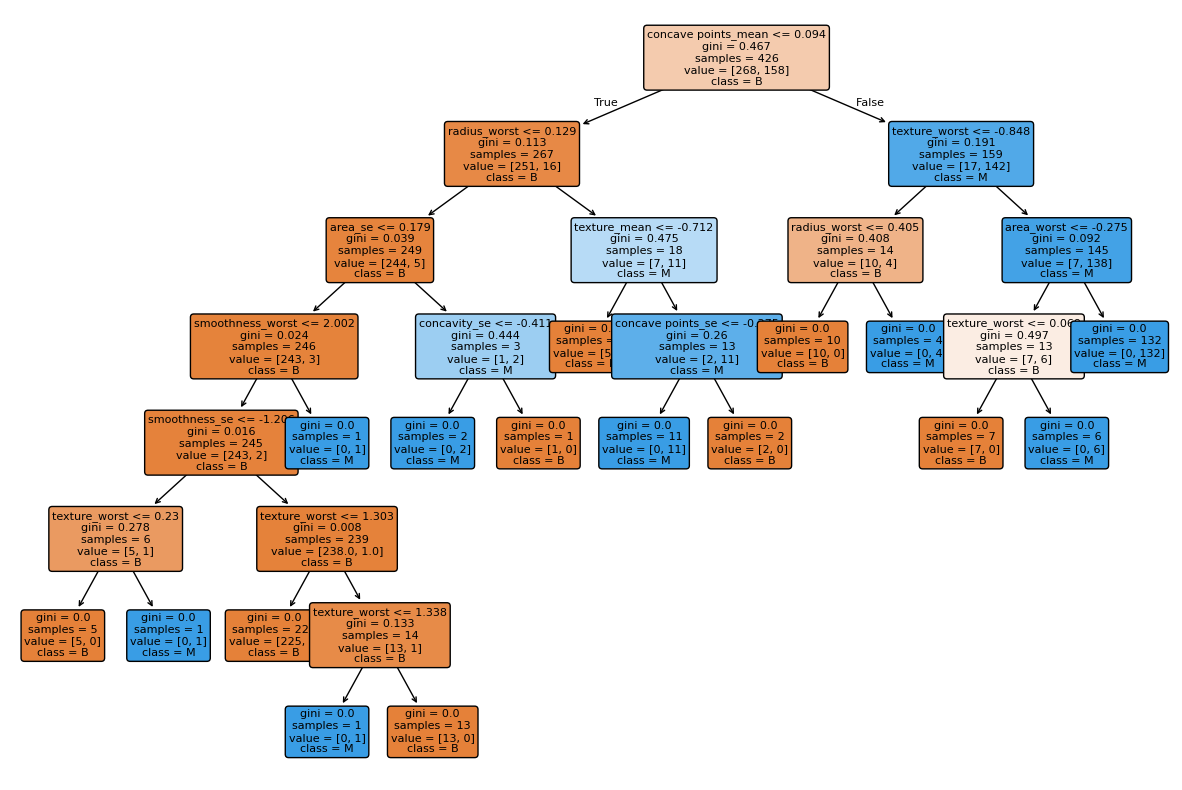

In [53]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15,10))

tree.plot_tree(
    Dt,
    filled=True,
    rounded=True,
    feature_names=x.columns,   # use original dataframe columns
    class_names=['B', 'M'],    # or ['0','1']
    fontsize=8
)

plt.show()